## 11 — Results

Collects all data tables and figures from the pipeline for the paper.

| Fig | Title | Source |
|-----|-------|--------|
| 1 | Stage 1 reductor × panel heatmap | 08 stage1_results.csv |
| 2 | Accuracy vs panel size (N=5–100) | 08 stage2_best.csv |
| 3 | Published panel comparison bar chart | 09 published_panel_results.csv + 08 stage2_best.csv |
| 4 | Confusion matrices — PAANDA-EA & published panels | 08 our_panels_oofpreds.pkl + 09 panel_oofpreds.pkl |
| 5 | Classifier robustness across panels | 09 published_panel_results.csv + 08 stage2_results.csv |
| 6 | SNP overlap heatmap | data/published_panels/ |

**Prerequisites**: run notebooks 08 and 09 first.

In [1]:
import sys, pickle, csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')

_root = next(p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'scripts' / 'config.py').exists())
sys.path.insert(0, str(_root / 'scripts'))
from notebook_init import setup
_cfg, PATHS, POPULATIONS, HARD_FILTERS, SITUATIONAL_FILTERS, ML = setup()

DIR08      = PATHS.outputs_dir('self_evaluation/08_unified_panel_sweep')
DIR09      = PATHS.outputs_dir('self_evaluation/09_published_panel_comparison')
PANELS_DIR = _root / 'data' / 'published_panels'
FIG_DIR    = PATHS.outputs_dir('self_evaluation/11_results')
FIG_DIR.mkdir(parents=True, exist_ok=True)
GRAPHS_DIR = _root / 'graphs'            # in-repo, git-tracked copy of all figures
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)

POP_LABELS = {'CN': 'Han', 'JPT': 'JPT', 'SEA': 'SEA'}

PLT_STYLE = {'figure.dpi': 300, 'axes.spines.top': False, 'axes.spines.right': False}
plt.rcParams.update(PLT_STYLE)

# ── Figure export ────────────────────────────────────────────────────────────
# PNG is always written (raster, 300 DPI). Add vector formats for publication:
#   'svg' — native in Microsoft Word 2016+/365 and scalable without quality loss
#   'pdf' — best for LaTeX / journal submission
# Set VECTOR_FORMATS = [] for PNG only.
SAVE_DPI       = 300
VECTOR_FORMATS = ['svg']

def save_fig(stem):
    """Save the current figure as PNG + each vector format to the scratch output dir
    (FIG_DIR) and the git-tracked graphs/ dir (GRAPHS_DIR)."""
    for d in (FIG_DIR, GRAPHS_DIR):
        plt.savefig(d / f'{stem}.png', dpi=SAVE_DPI, bbox_inches='tight')
        for fmt in VECTOR_FORMATS:
            plt.savefig(d / f'{stem}.{fmt}', bbox_inches='tight')
    fmts = ', '.join(['png'] + VECTOR_FORMATS)
    print(f'Saved {stem} ({fmts}) -> {FIG_DIR} and {GRAPHS_DIR}')
print('Output dir:', FIG_DIR)

Project root : /home/ibmelab/Projects/AISNP_Research
genomes_data : /mnt/data/aisnp_data/1000genomes/
output root  : output
Output dir: /mnt/data/aisnp_data/1000genomes/outputs/self_evaluation/11_results


In [2]:
# Load all data
s2_best    = pd.read_csv(DIR08 / 'stage2_best.csv')
s2_results = pd.read_csv(DIR08 / 'stage2_results.csv')
s1_results = pd.read_csv(DIR08 / 'stage1_results.csv')
s3_results = pd.read_csv(DIR08 / 'stage3_results.csv')
pub_res    = pd.read_csv(DIR09 / 'published_panel_results.csv')

with open(DIR09 / 'panel_oofpreds.pkl', 'rb') as f:
    oof_data = pickle.load(f)
oofpreds = oof_data['oofpreds']
classes  = oof_data['classes']
classes_display = [POP_LABELS.get(c, c) for c in classes]

with open(DIR08 / 'our_panels_oofpreds.pkl', 'rb') as f:
    our_oof_data = pickle.load(f)
our_oofpreds = our_oof_data['oofpreds']

print('stage1_results:', s1_results.shape)
print('stage2_best:   ', s2_best.shape)
print('pub_results:   ', pub_res.shape)
print('OOF panels (published):', list(oofpreds.keys()))
print('OOF panels (PAANDA-EA):     ', list(our_oofpreds.keys()))
print('Display classes:       ', classes_display)

stage1_results: (162, 5)
stage2_best:    (18, 9)
pub_results:    (36, 7)
OOF panels (published): ['shi_36', 'shi_59', 'shi_98', 'shi_142', 'cao_19', 'cai_eas34']
OOF panels (PAANDA-EA):      ['N=35', 'N=50', 'N=70']
Display classes:        ['Han', 'JPT', 'SEA']


---
## Figure 1 — Stage 1 Reductor × Panel Heatmap

Saved fig1_stage1_heatmap (png, svg) -> /mnt/data/aisnp_data/1000genomes/outputs/self_evaluation/11_results and /home/ibmelab/Projects/AISNP_Research/graphs


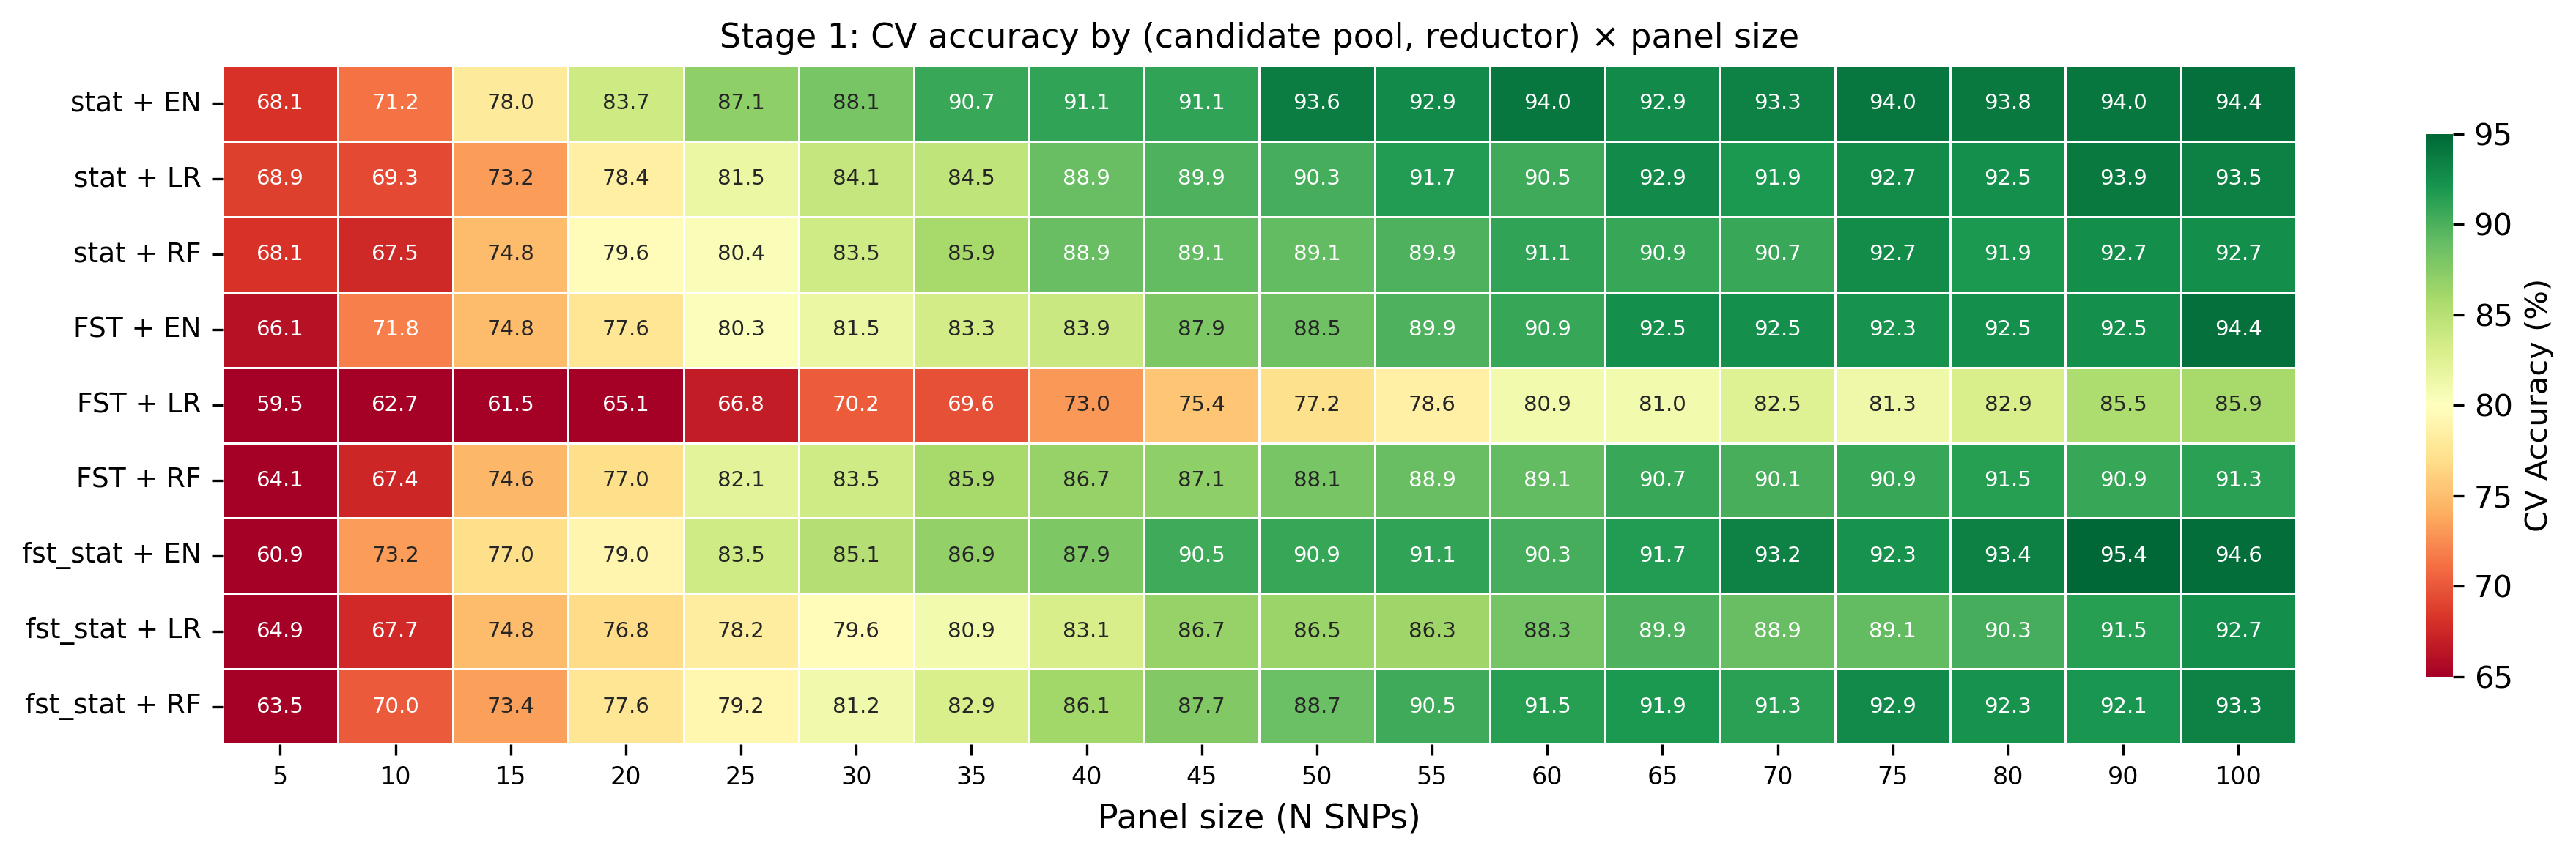

In [3]:
s1 = s1_results.copy()
s1['config'] = s1['panel'] + ' + ' + s1['reductor']
pivot = s1.pivot_table(index='config', columns='n_snps', values='acc_mean')

row_order = [r for r in [
    'stat + EN', 'stat + LR', 'stat + RF',
    'FST + EN',  'FST + LR',  'FST + RF',
    'fst_stat + EN', 'fst_stat + LR', 'fst_stat + RF'
] if r in pivot.index]
pivot = pivot.loc[row_order]

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(pivot * 100, ax=ax, cmap='RdYlGn', vmin=65, vmax=95,
            annot=True, fmt='.1f', annot_kws={'size': 7},
            linewidths=0.3,
            cbar_kws={'label': 'CV Accuracy (%)', 'shrink': 0.8})

ax.set_xlabel('Panel size (N SNPs)', fontsize=11)
ax.set_ylabel('')
ax.set_title('Stage 1: CV accuracy by (candidate pool, reductor) × panel size', fontsize=11)
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
save_fig('fig1_stage1_heatmap')
plt.show()

---
## Figure 2 — Accuracy vs Panel Size

Saved fig2_accuracy_vs_n (png, svg) -> /mnt/data/aisnp_data/1000genomes/outputs/self_evaluation/11_results and /home/ibmelab/Projects/AISNP_Research/graphs


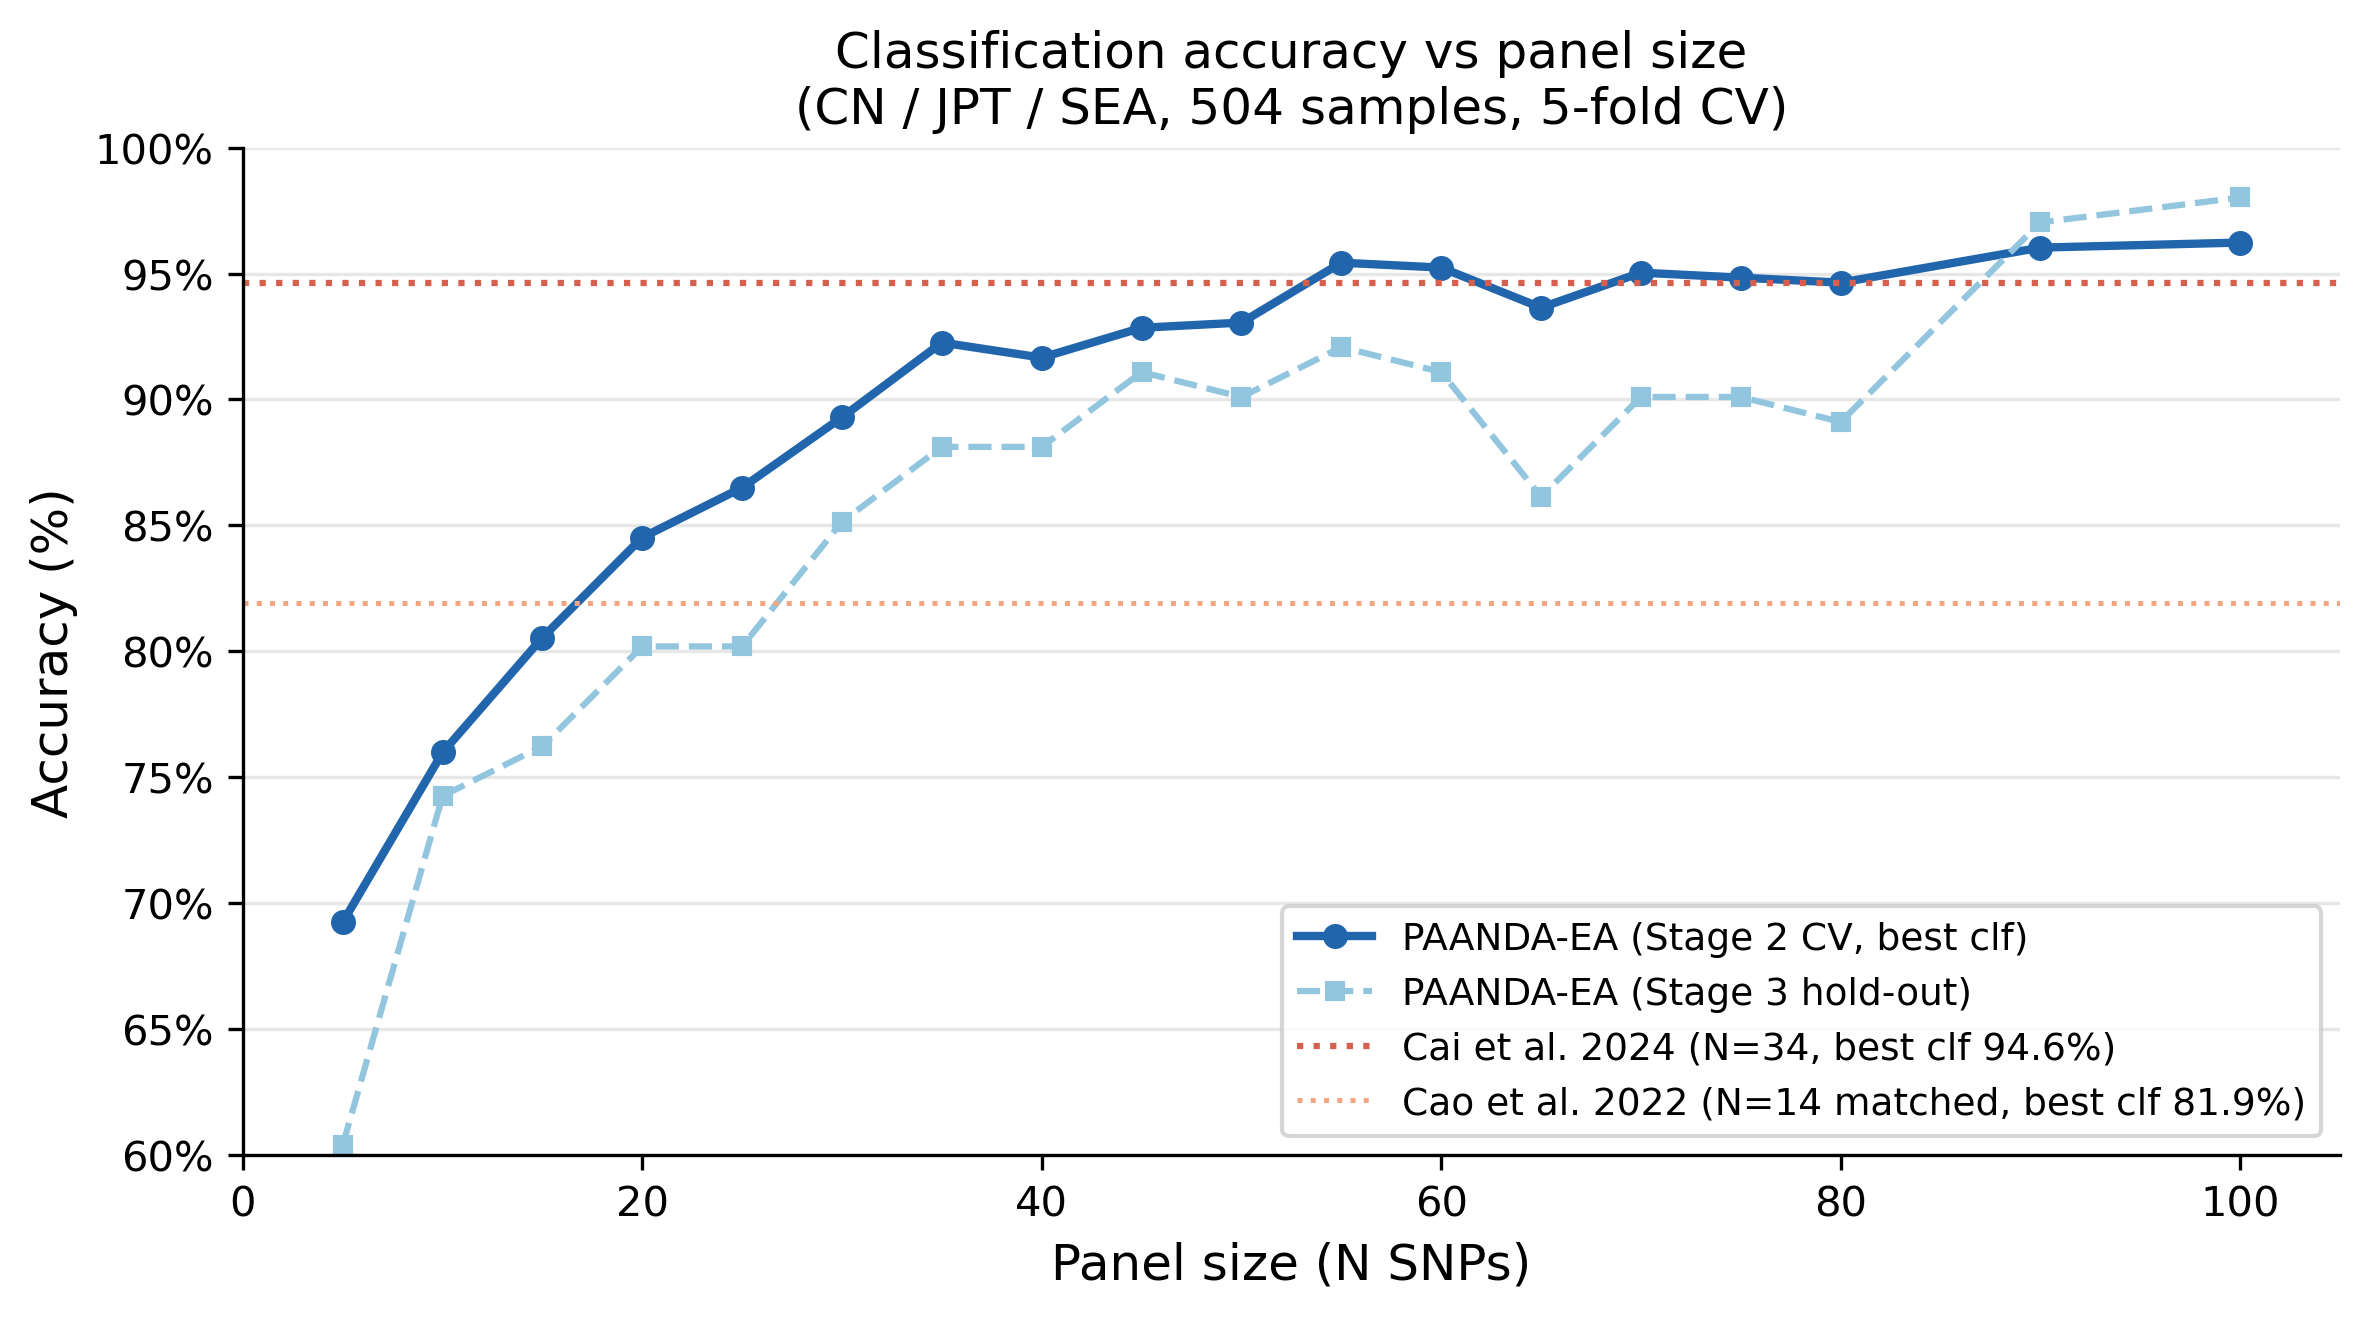

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(s2_best['n_snps'], s2_best['acc_mean'] * 100,
        'o-', color='#2166ac', linewidth=2, markersize=5,
        label='PAANDA-EA (Stage 2 CV, best clf)')
ax.plot(s3_results['n_snps'], s3_results['acc'] * 100,
        's--', color='#92c5de', linewidth=1.5, markersize=4,
        label='PAANDA-EA (Stage 3 hold-out)')

cai_best = pub_res[pub_res['panel'] == 'cai_eas34']['acc'].max() * 100
cao_best = pub_res[pub_res['panel'] == 'cao_19']['acc'].max()   * 100
ax.axhline(cai_best, color='#d6604d', linewidth=1.5, linestyle=':',
           label=f'Cai et al. 2024 (N=34, best clf {cai_best:.1f}%)')
ax.axhline(cao_best, color='#f4a582', linewidth=1.2, linestyle=':',
           label=f'Cao et al. 2022 (N=14 matched, best clf {cao_best:.1f}%)')

ax.set_xlabel('Panel size (N SNPs)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Classification accuracy vs panel size\n(CN / JPT / SEA, 504 samples, 5-fold CV)', fontsize=12)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))
ax.set_xlim(0, 105)
ax.set_ylim(60, 100)
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
save_fig('fig2_accuracy_vs_n')
plt.show()

---
## Figure 3 — Published Panel Comparison

Saved fig3_panel_comparison (png, svg) -> /mnt/data/aisnp_data/1000genomes/outputs/self_evaluation/11_results and /home/ibmelab/Projects/AISNP_Research/graphs


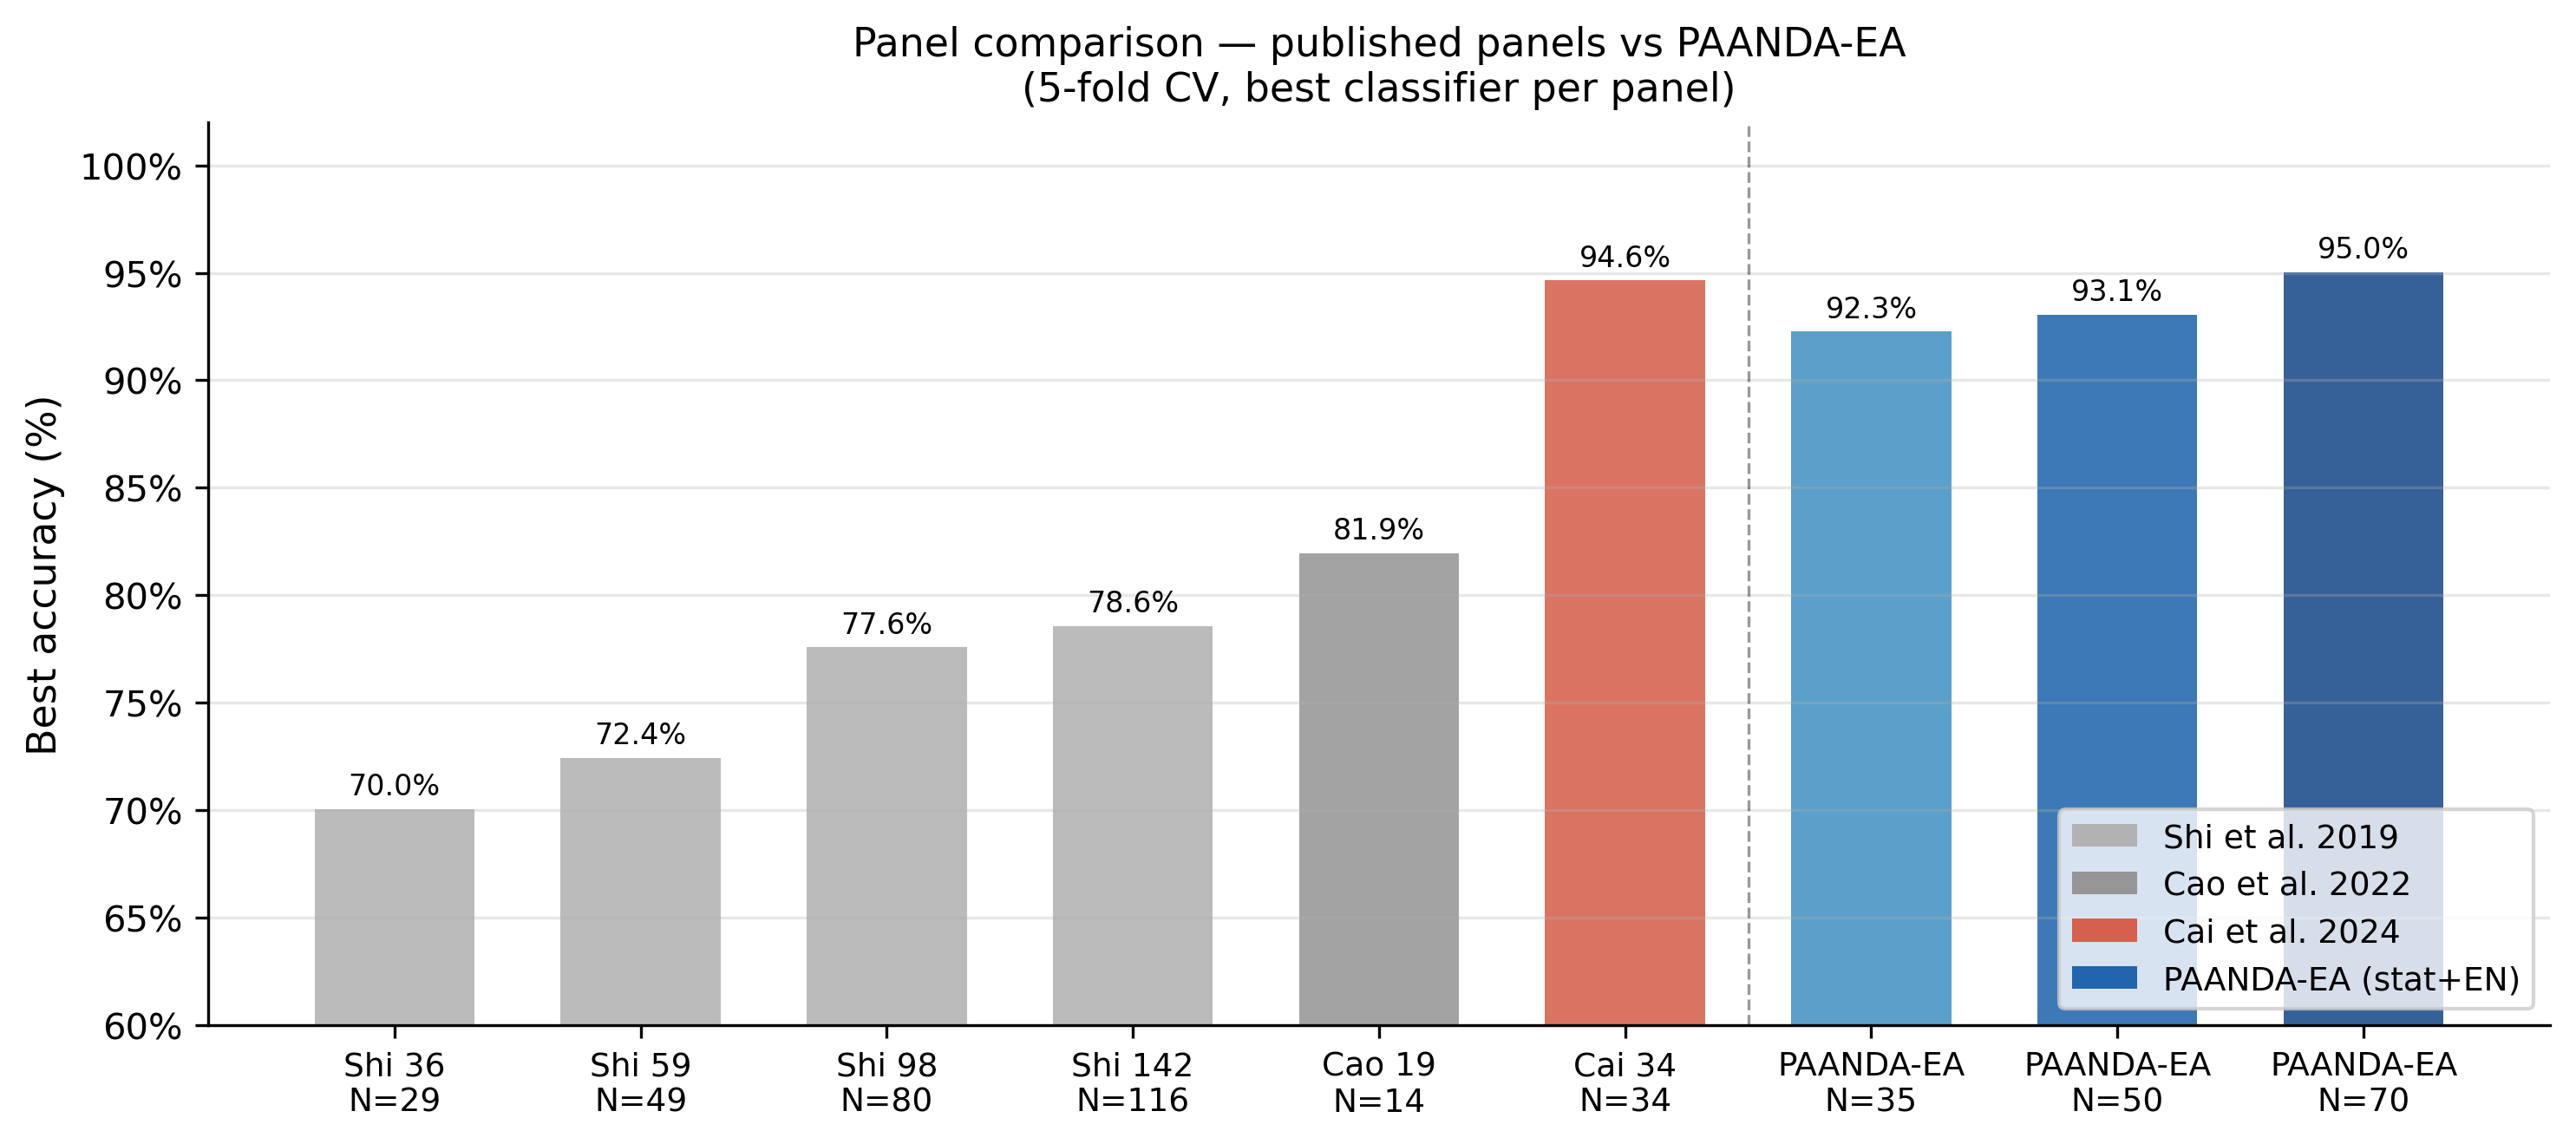

In [5]:
pub_best = pub_res.groupby('panel')['acc'].max().reset_index()
pub_best['n_snps'] = pub_res.groupby('panel')['n_snps'].first().values

our_pts = s2_best[s2_best['n_snps'].isin([35, 50, 70])][['n_snps','acc_mean']].copy()
our_pts.columns = ['n_snps', 'acc']
our_pts['panel'] = our_pts['n_snps'].apply(lambda n: f'PAANDA-EA N={n}')

panel_order = ['shi_36','shi_59','shi_98','shi_142','cao_19','cai_eas34',
               'PAANDA-EA N=35','PAANDA-EA N=50','PAANDA-EA N=70']
all_pts = pd.concat([pub_best, our_pts], ignore_index=True)
all_pts = all_pts.set_index('panel').reindex(panel_order).reset_index()

labels = [
    f"Shi 36\nN={int(all_pts.loc[0,'n_snps'])}",
    f"Shi 59\nN={int(all_pts.loc[1,'n_snps'])}",
    f"Shi 98\nN={int(all_pts.loc[2,'n_snps'])}",
    f"Shi 142\nN={int(all_pts.loc[3,'n_snps'])}",
    f"Cao 19\nN={int(all_pts.loc[4,'n_snps'])}",
    "Cai 34\nN=34",
    "PAANDA-EA\nN=35", "PAANDA-EA\nN=50", "PAANDA-EA\nN=70"
]
bar_colors = ['#b2b2b2']*4 + ['#969696'] + ['#d6604d'] + ['#4393c3','#2166ac','#1a4a8a']

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(range(len(all_pts)), all_pts['acc'] * 100,
              color=bar_colors, alpha=0.88, width=0.65)

for bar, val in zip(bars, all_pts['acc']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{val*100:.1f}%', ha='center', va='bottom', fontsize=8)

ax.set_xticks(range(len(all_pts)))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Best accuracy (%)', fontsize=11)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))
ax.set_ylim(60, 102)
ax.set_title('Panel comparison — published panels vs PAANDA-EA\n(5-fold CV, best classifier per panel)', fontsize=11)
ax.axvline(5.5, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax.grid(axis='y', alpha=0.3)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#b2b2b2', label='Shi et al. 2019'),
    Patch(facecolor='#969696', label='Cao et al. 2022'),
    Patch(facecolor='#d6604d', label='Cai et al. 2024'),
    Patch(facecolor='#2166ac', label='PAANDA-EA (stat+EN)'),
], fontsize=9, loc='lower right')

plt.tight_layout()
save_fig('fig3_panel_comparison')
plt.show()

---
## Figure 4 — Confusion Matrices: PAANDA-EA vs Published Panels

Saved fig4_confusion (png, svg) -> /mnt/data/aisnp_data/1000genomes/outputs/self_evaluation/11_results and /home/ibmelab/Projects/AISNP_Research/graphs


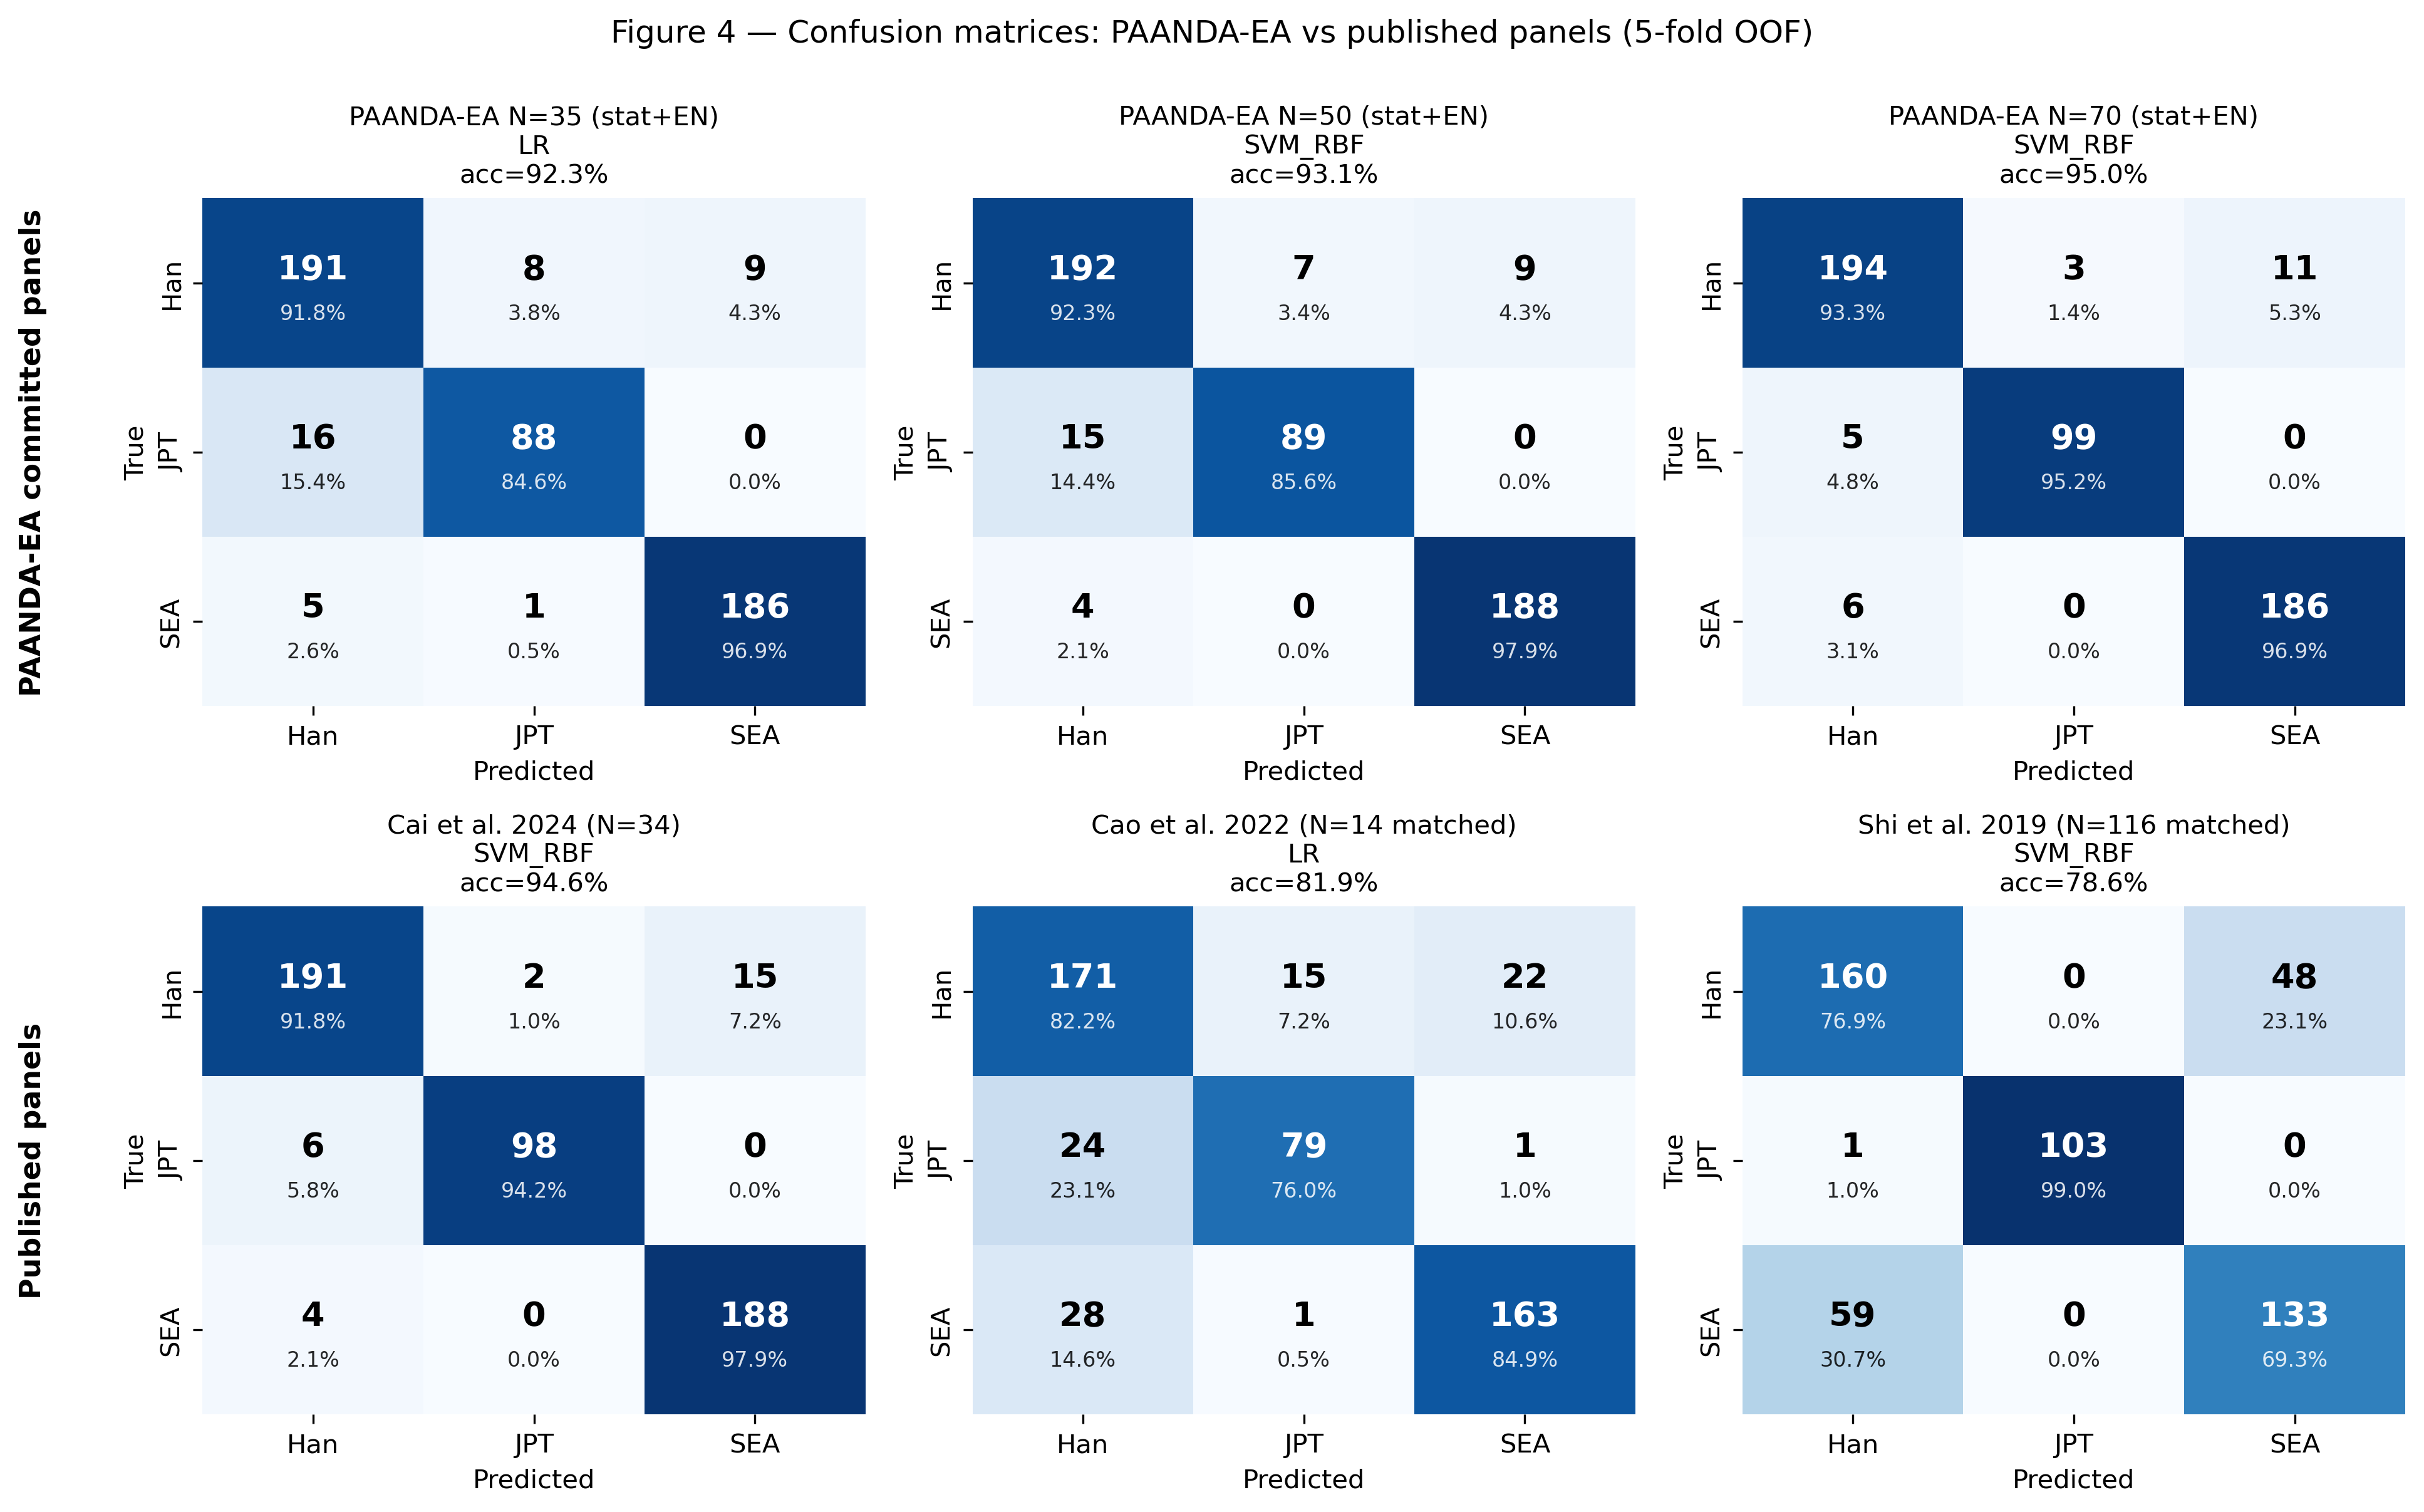

In [6]:
def draw_cm(ax, y_true, y_pred, title):
    cm     = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, ax=ax, annot=False, cmap='Blues',
                xticklabels=classes_display, yticklabels=classes_display,
                vmin=0, vmax=100, cbar=False)
    for i in range(3):
        for j in range(3):
            color = 'white' if cm_pct[i, j] > 60 else 'black'
            ax.text(j+0.5, i+0.42, str(cm[i,j]),
                    ha='center', va='center', fontsize=13, fontweight='bold', color=color)
            ax.text(j+0.5, i+0.68, f'{cm_pct[i,j]:.1f}%',
                    ha='center', va='center', fontsize=8, color=color, alpha=0.85)
    acc = np.diag(cm).sum() / cm.sum() * 100
    ax.set_title(f'{title}\nacc={acc:.1f}%', fontsize=10)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('True', fontsize=10)

def best_clf_for(panel_name):
    rows = pub_res[pub_res['panel'] == panel_name]
    return rows.loc[rows['acc'].idxmax(), 'classifier'] if not rows.empty else None

# Top row — PAANDA-EA committed panels; bottom row — published panels
our_panels = [
    ('N=35', s2_best[s2_best['n_snps']==35]['classifier'].iloc[0], 'PAANDA-EA N=35 (stat+EN)'),
    ('N=50', s2_best[s2_best['n_snps']==50]['classifier'].iloc[0], 'PAANDA-EA N=50 (stat+EN)'),
    ('N=70', s2_best[s2_best['n_snps']==70]['classifier'].iloc[0], 'PAANDA-EA N=70 (stat+EN)'),
]
pub_panels = [
    ('cai_eas34', best_clf_for('cai_eas34'), 'Cai et al. 2024 (N=34)'),
    ('cao_19',    best_clf_for('cao_19'),    'Cao et al. 2022 (N=14 matched)'),
    ('shi_142',   best_clf_for('shi_142'),   'Shi et al. 2019 (N=116 matched)'),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))

for ax, (key, clf, title) in zip(axes[0], our_panels):
    y_true, y_pred = our_oofpreds[key]
    draw_cm(ax, y_true, y_pred, f'{title}\n{clf}')

for ax, (pname, clf, title) in zip(axes[1], pub_panels):
    y_true, y_pred = oofpreds[pname][clf]
    draw_cm(ax, y_true, y_pred, f'{title}\n{clf}')

axes[0, 0].annotate('PAANDA-EA committed panels', xy=(0, 0.5), xytext=(-65, 0),
                    xycoords='axes fraction', textcoords='offset points',
                    ha='center', va='center', rotation=90, fontsize=11, fontweight='bold')
axes[1, 0].annotate('Published panels', xy=(0, 0.5), xytext=(-65, 0),
                    xycoords='axes fraction', textcoords='offset points',
                    ha='center', va='center', rotation=90, fontsize=11, fontweight='bold')

plt.suptitle('Figure 4 — Confusion matrices: PAANDA-EA vs published panels (5-fold OOF)',
             fontsize=12, y=1.00)
plt.tight_layout()
save_fig('fig4_confusion')
plt.show()

---
## Figure 5 — Classifier Robustness

Saved fig5_classifier_robustness (png, svg) -> /mnt/data/aisnp_data/1000genomes/outputs/self_evaluation/11_results and /home/ibmelab/Projects/AISNP_Research/graphs


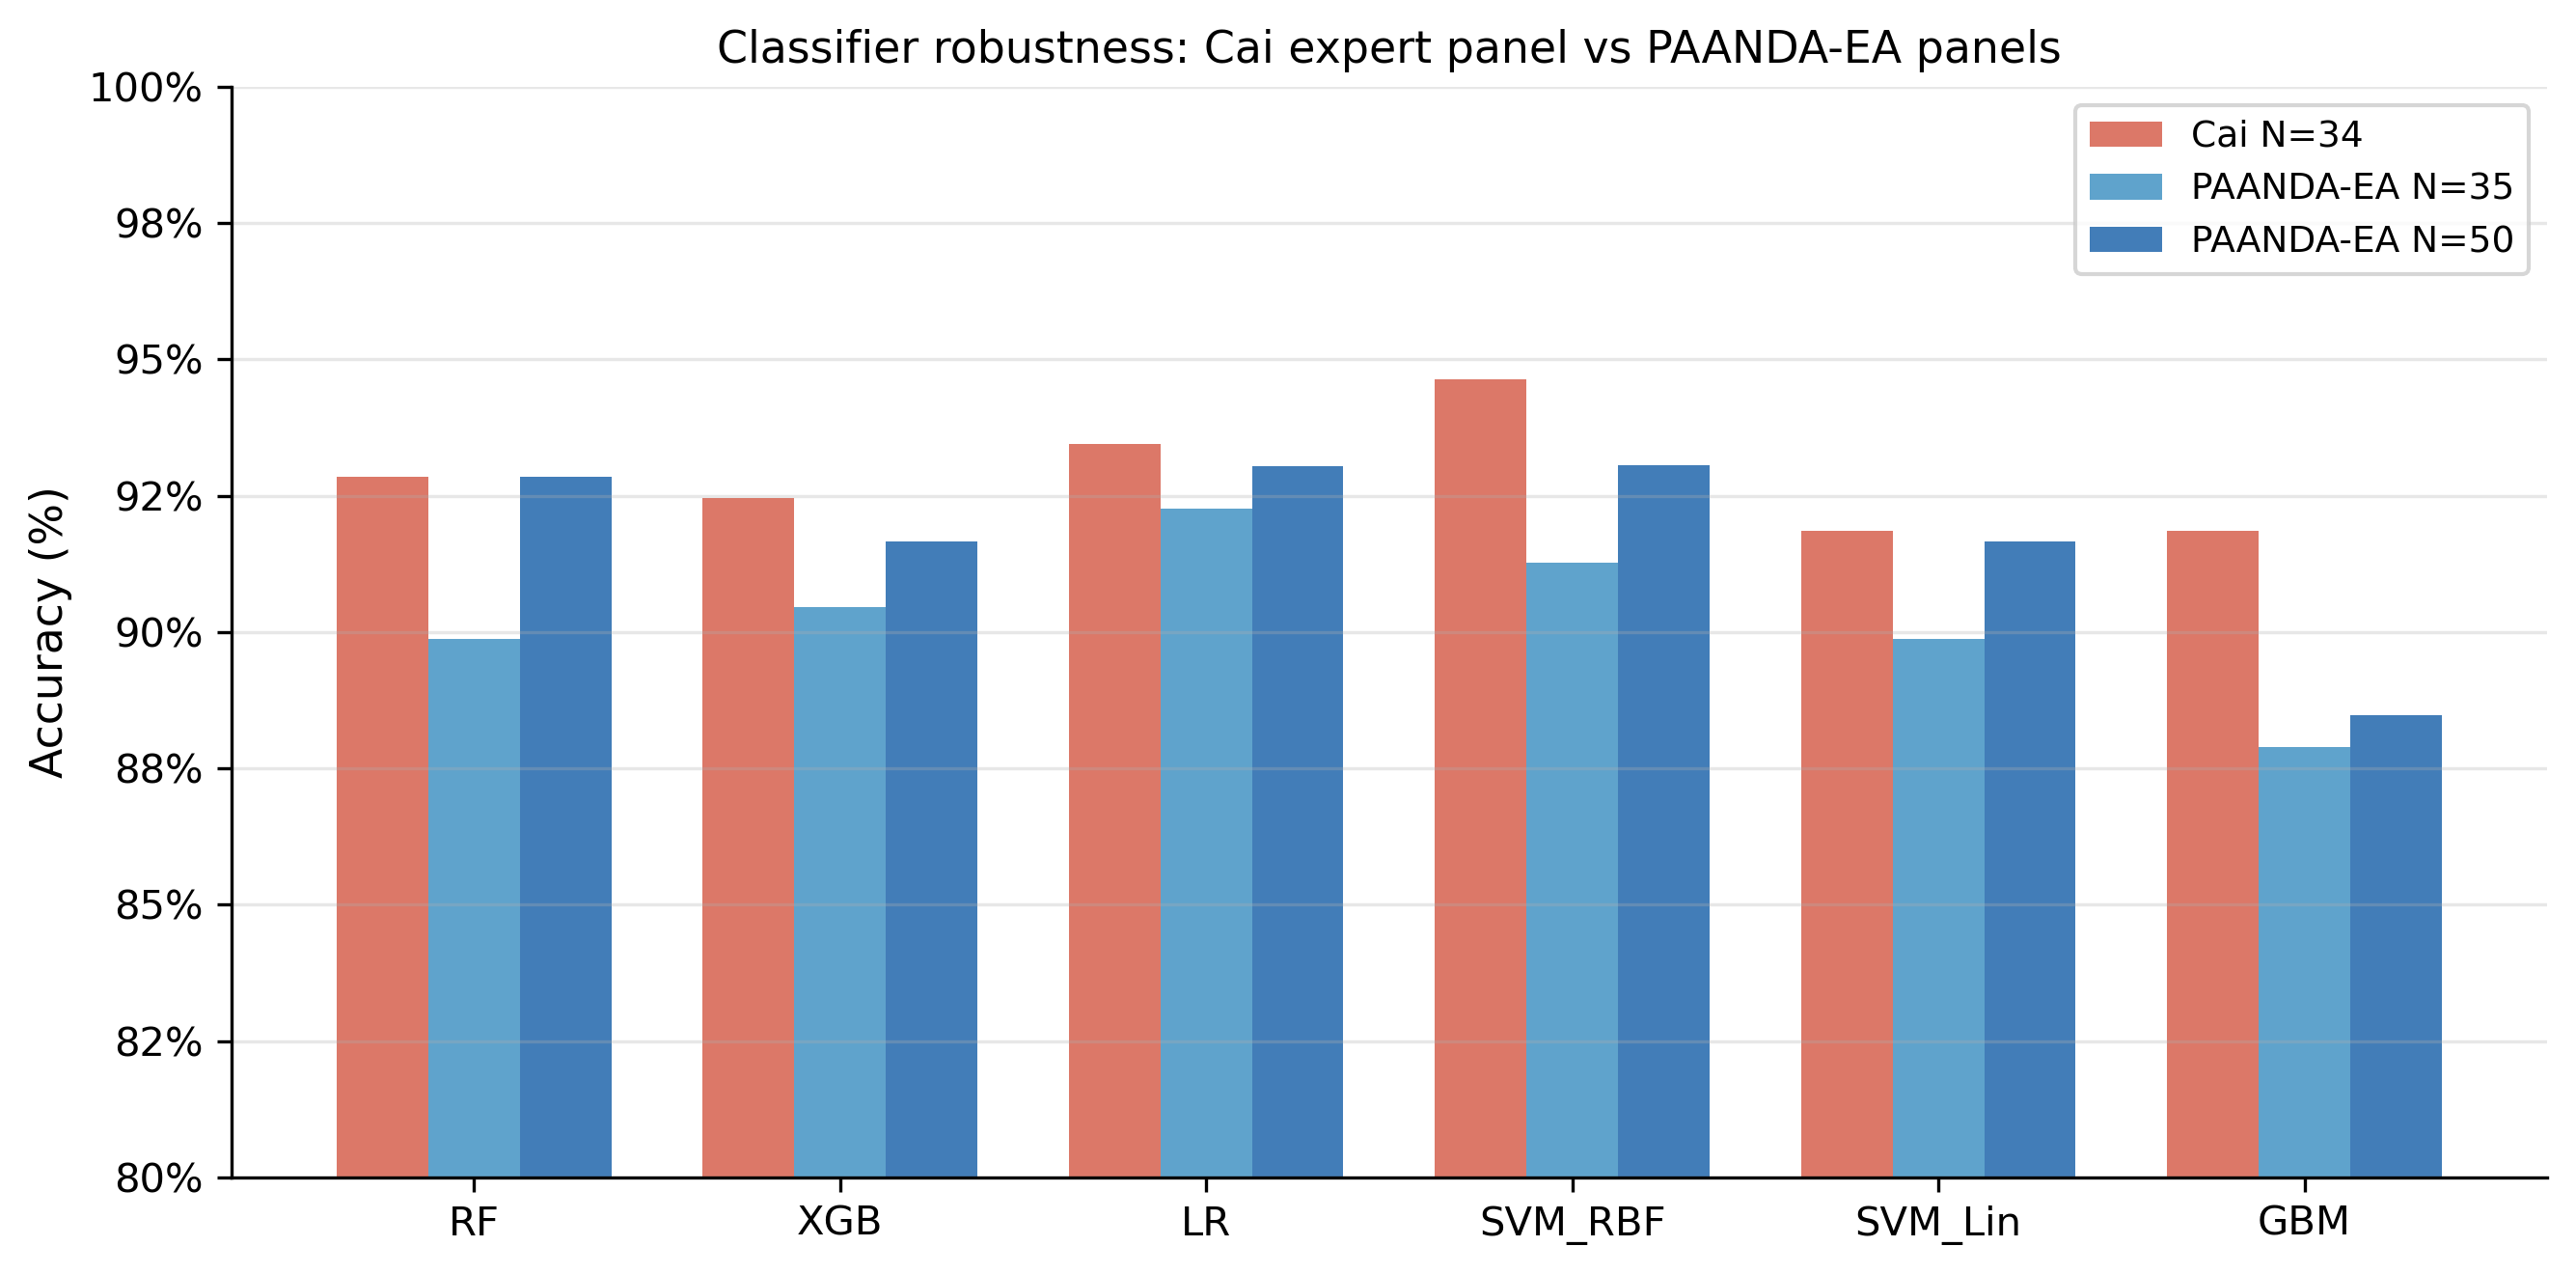

In [7]:
our35 = s2_results[s2_results['n_snps'] == 35].groupby('classifier')['acc'].mean().reset_index()
our35['panel_label'] = 'PAANDA-EA N=35'
our50 = s2_results[s2_results['n_snps'] == 50].groupby('classifier')['acc'].mean().reset_index()
our50['panel_label'] = 'PAANDA-EA N=50'
cai_df = pub_res[pub_res['panel'] == 'cai_eas34'][['classifier','acc']].copy()
cai_df['panel_label'] = 'Cai N=34'

combined    = pd.concat([our35, our50, cai_df], ignore_index=True)
clf_order   = ['RF', 'XGB', 'LR', 'SVM_RBF', 'SVM_Lin', 'GBM']
panel_order = ['Cai N=34', 'PAANDA-EA N=35', 'PAANDA-EA N=50']
colors      = {'Cai N=34': '#d6604d', 'PAANDA-EA N=35': '#4393c3', 'PAANDA-EA N=50': '#2166ac'}

fig, ax = plt.subplots(figsize=(9, 4.5))
x     = np.arange(len(clf_order))
width = 0.25

for i, plabel in enumerate(panel_order):
    sub  = combined[combined['panel_label'] == plabel].set_index('classifier')
    vals = [sub.loc[c, 'acc'] * 100 if c in sub.index else np.nan for c in clf_order]
    ax.bar(x + (i - 1) * width, vals, width,
           label=plabel, color=colors[plabel], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(clf_order, fontsize=10)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))
ax.set_ylim(80, 100)
ax.set_title('Classifier robustness: Cai expert panel vs PAANDA-EA panels', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
save_fig('fig5_classifier_robustness')
plt.show()

---
## Figure 6 — SNP Overlap Heatmap

  Shi 36      : 36 SNPs
  Shi 59      : 59 SNPs
  Shi 98      : 98 SNPs
  Shi 142     : 142 SNPs
  Cao 19      : 19 SNPs
  Cai 34      : 34 SNPs
  PAANDA-EA N=35: 35 SNPs
  PAANDA-EA N=50: 50 SNPs
  PAANDA-EA N=70: 70 SNPs
Saved fig6_overlap_heatmap (png, svg) -> /mnt/data/aisnp_data/1000genomes/outputs/self_evaluation/11_results and /home/ibmelab/Projects/AISNP_Research/graphs


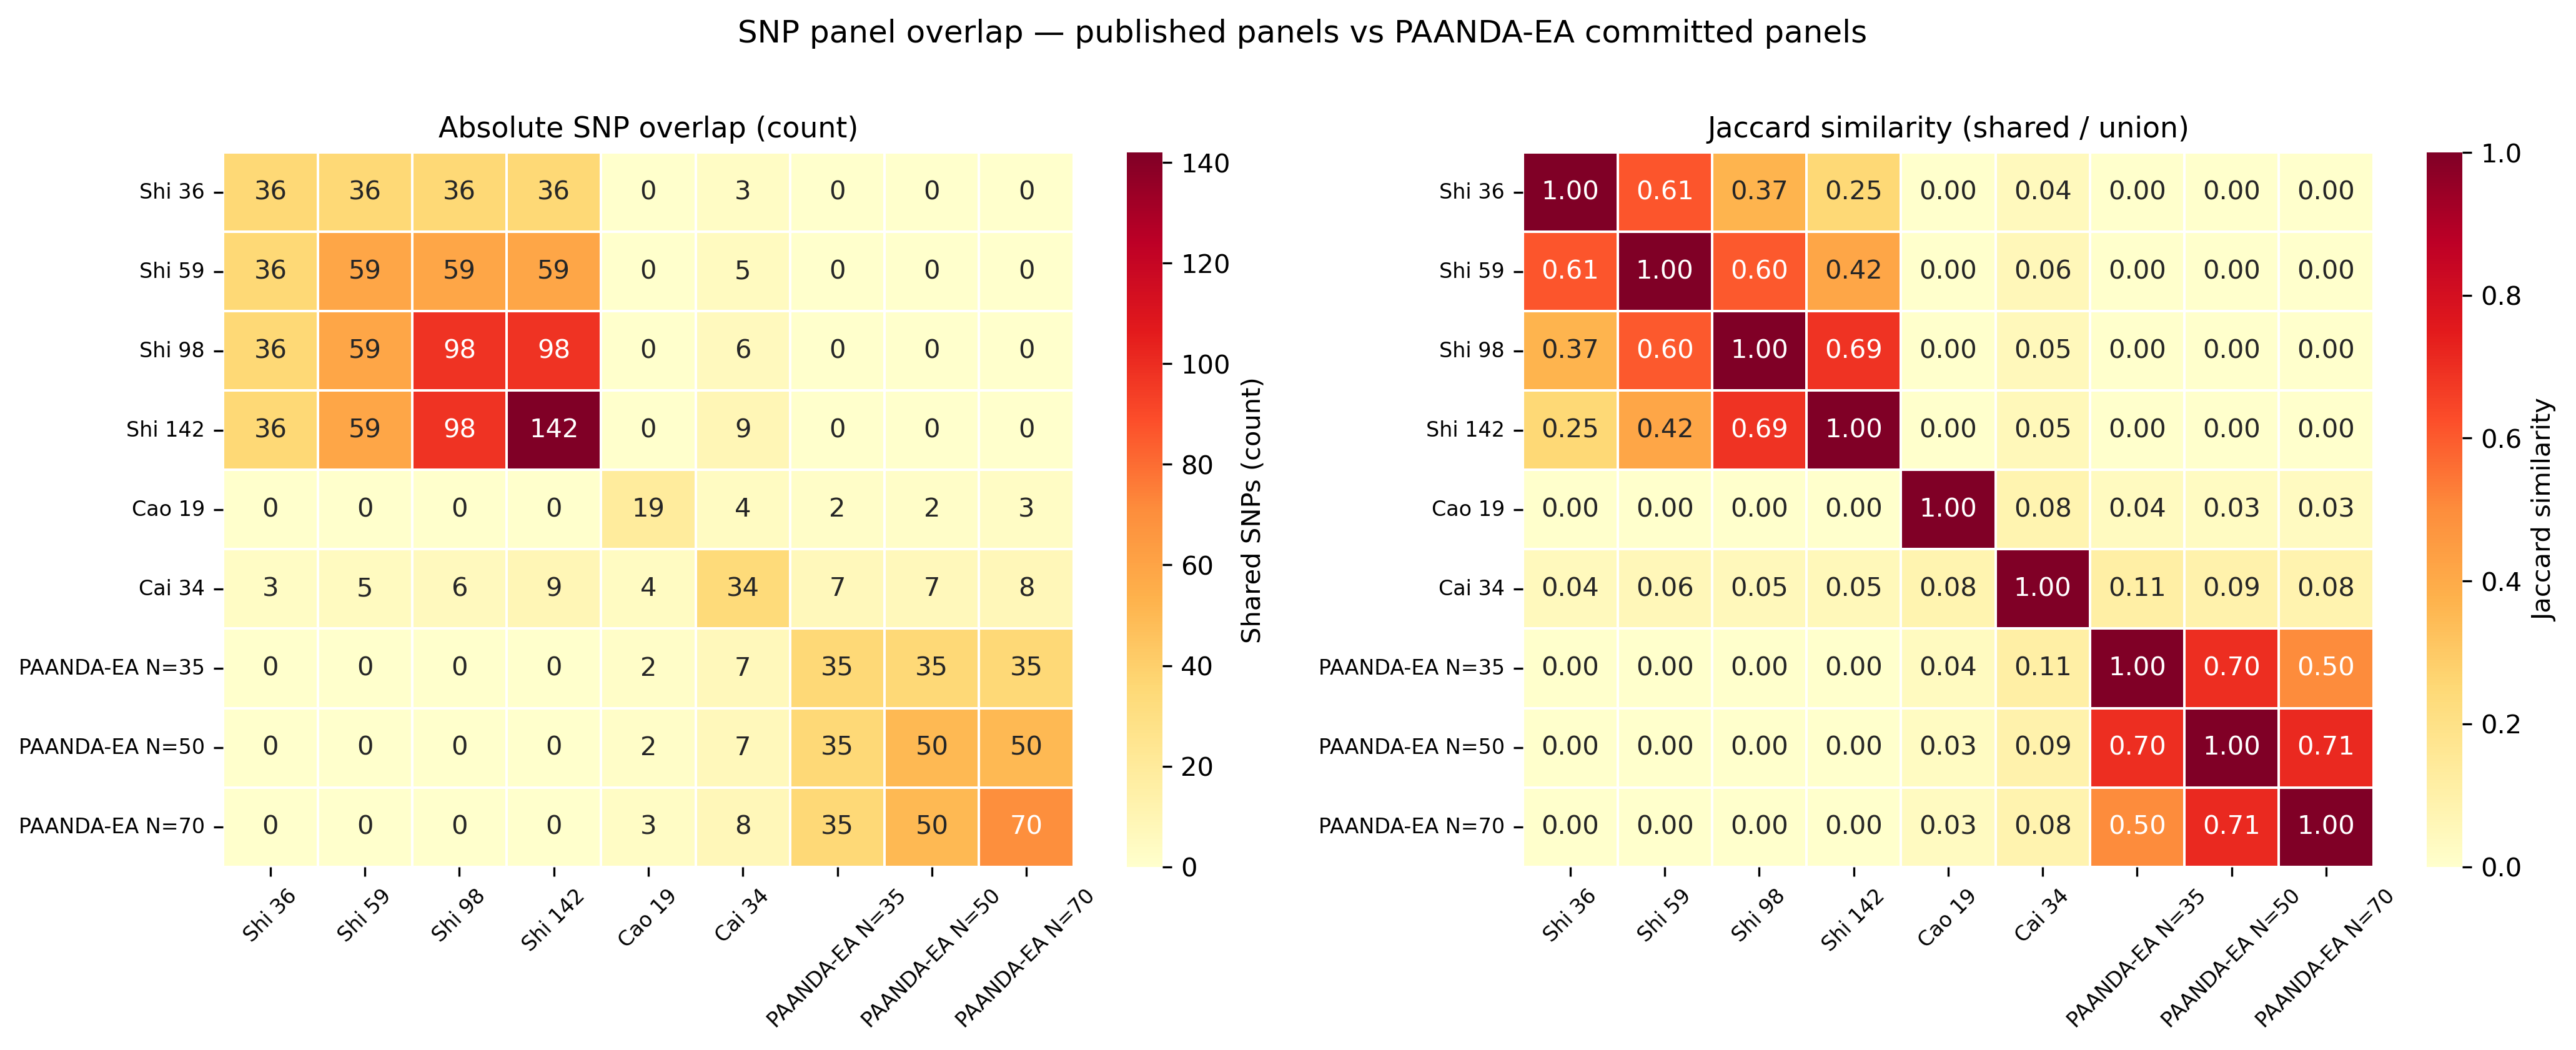

In [8]:
def load_txt(fname):
    return set(l.strip() for l in open(PANELS_DIR / fname) if l.strip())

cai_coords_list = []
with open(PANELS_DIR / 'cai_eas34_coords.tsv') as f:
    for line in f:
        cai_coords_list.append(line.strip().split('\t')[2])

rsid_map = {}
with open(PANELS_DIR / 'our_panels_rsid_map.tsv') as f:
    for row in csv.DictReader(f, delimiter='\t'):
        rsid_map[row['snp_id']] = row['rsid']

OUR_PANELS_DIR = PATHS.outputs_dir('self_evaluation/08_unified_panel_sweep') / 'panels'

def load_our_panel(n):
    p = OUR_PANELS_DIR / f'panel_N{n:03d}.csv'
    if not p.exists(): return set()
    rsids = set()
    with open(p) as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            rsid = rsid_map.get(row[1])
            if rsid: rsids.add(rsid)
    return rsids

panel_sets = {
    'Shi 36':    load_txt('shi_36.txt'),
    'Shi 59':    load_txt('shi_59.txt'),
    'Shi 98':    load_txt('shi_98.txt'),
    'Shi 142':   load_txt('shi_142.txt'),
    'Cao 19':    load_txt('cao_19.txt'),
    'Cai 34':    set(cai_coords_list),
    'PAANDA-EA N=35': load_our_panel(35),
    'PAANDA-EA N=50': load_our_panel(50),
    'PAANDA-EA N=70': load_our_panel(70),
}

for k, v in panel_sets.items():
    print(f'  {k:<12}: {len(v)} SNPs')

keys    = list(panel_sets.keys())
n       = len(keys)
mat_jac = np.zeros((n, n))
mat_abs = np.zeros((n, n), dtype=int)
for i, k1 in enumerate(keys):
    for j, k2 in enumerate(keys):
        inter         = len(panel_sets[k1] & panel_sets[k2])
        union         = len(panel_sets[k1] | panel_sets[k2])
        mat_jac[i, j] = inter / union if union > 0 else 0
        mat_abs[i, j] = inter

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.heatmap(mat_abs, ax=axes[0], annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=keys, yticklabels=keys, linewidths=0.5,
            cbar_kws={'label': 'Shared SNPs (count)'})
axes[0].set_title('Absolute SNP overlap (count)', fontsize=11)
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', rotation=0,  labelsize=8)

sns.heatmap(mat_jac, ax=axes[1], annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=keys, yticklabels=keys, linewidths=0.5,
            vmin=0, vmax=1, cbar_kws={'label': 'Jaccard similarity'})
axes[1].set_title('Jaccard similarity (shared / union)', fontsize=11)
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle('SNP panel overlap — published panels vs PAANDA-EA committed panels', fontsize=12, y=1.01)
plt.tight_layout()
save_fig('fig6_overlap_heatmap')
plt.show()

---
## Key Tables

In [9]:
# Table 1 — Stage 2 accuracy for all 6 classifiers at key panel sizes (stat + ElasticNet)
key_n     = [35, 50, 70]
clf_order = ['RF', 'XGB', 'LR', 'SVM_RBF', 'SVM_Lin', 'GBM']

sub   = s2_results[s2_results['n_snps'].isin(key_n)].copy()
pivot = sub.pivot_table(index='classifier', columns='n_snps', values='acc', aggfunc='mean')
pivot = pivot.reindex(clf_order) * 100
pivot.columns = [f'N={c} Acc (%)' for c in pivot.columns]
pivot = pivot.round(2)
pivot.index.name = 'Classifier'
t1 = pivot.reset_index()

print('Table 1 — Stage 2 accuracy (stat + ElasticNet reductor, 5-fold CV, all classifiers)')
display(t1.style.highlight_max(subset=[c for c in t1.columns if 'Acc' in c],
                                axis=0, props='font-weight: bold'))
t1.to_csv(FIG_DIR / 'table1_our_pipeline.csv', index=False)

print()

# Table 2 — Published panels vs PAANDA-EA committed panels (best classifier per panel)
pub_best_full = pub_res.loc[pub_res.groupby('panel')['acc'].idxmax()].copy()
pub_order = ['shi_36','shi_59','shi_98','shi_142','cao_19','cai_eas34']
t2_pub = pub_best_full.set_index('panel').reindex(pub_order).reset_index()
t2_pub = t2_pub[['panel','n_snps','classifier','acc','f1','mcc','roc_auc']]
t2_pub.columns = ['Panel','Matched N','Best clf','Accuracy','F1','MCC','ROC-AUC']

# PAANDA-EA committed panels — best classifier per N from Stage 2 (acc-selected)
our_best = s2_best[s2_best['n_snps'].isin([35, 50, 70])].copy().sort_values('n_snps')
our_best['Panel'] = 'PAANDA-EA N=' + our_best['n_snps'].astype(int).astype(str)
t2_our = our_best[['Panel','n_snps','classifier','acc_mean','f1_mean','mcc_mean','roc_auc_mean']]
t2_our.columns = ['Panel','Matched N','Best clf','Accuracy','F1','MCC','ROC-AUC']

t2 = pd.concat([t2_pub, t2_our], ignore_index=True)
t2[['Accuracy','F1','MCC','ROC-AUC']] = t2[['Accuracy','F1','MCC','ROC-AUC']].round(4)

print('Table 2 — Published panels vs PAANDA-EA committed panels (best classifier, 5-fold CV on our 504-sample cohort)')
display(t2)
t2.to_csv(FIG_DIR / 'table2_published_panels.csv', index=False)

print(f'\nCSVs saved to {FIG_DIR}')

Table 1 — Stage 2 accuracy (stat + ElasticNet reductor, 5-fold CV, all classifiers)


,Classifier,N=35 Acc (%),N=50 Acc (%),N=70 Acc (%)
0,RF,89.880000,92.850000,93.850000
1,XGB,90.470000,91.660000,93.260000
2,LR,92.260000,93.050000,94.440000
3,SVM_RBF,91.270000,93.050000,95.040000
4,SVM_Lin,89.870000,91.670000,93.850000
5,GBM,87.890000,88.480000,92.260000



Table 2 — Published panels vs PAANDA-EA committed panels (best classifier, 5-fold CV on our 504-sample cohort)


,Panel,Matched N,Best clf,Accuracy,F1,MCC,ROC-AUC
0,shi_36,29,LR,0.7005,0.6992,0.5359,0.8469
1,shi_59,49,SVM_RBF,0.7242,0.7223,0.5725,0.8560
2,shi_98,80,SVM_RBF,0.7758,0.7744,0.6541,0.8952
3,shi_142,116,SVM_RBF,0.7857,0.7850,0.6680,0.9087
4,cao_19,14,LR,0.8194,0.8190,0.7188,0.9428
5,cai_eas34,34,SVM_RBF,0.9464,0.9464,0.9174,0.9909
6,PAANDA-EA N=35,35,LR,0.9226,0.9222,0.8798,0.9801
7,PAANDA-EA N=50,50,SVM_RBF,0.9305,0.9297,0.8925,0.9838
8,PAANDA-EA N=70,70,SVM_RBF,0.9504,0.9502,0.9234,0.9910



CSVs saved to /mnt/data/aisnp_data/1000genomes/outputs/self_evaluation/11_results
